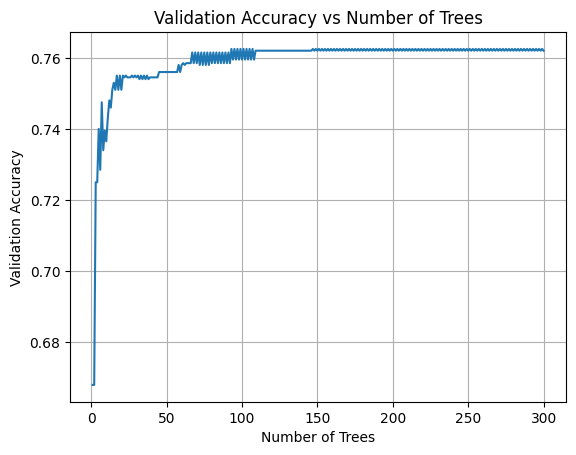

Best number of trees: 93
Test Accuracy: 0.7719738824711201


In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("mnist.npz")
X_train, y_train = data["x_train"], data["y_train"]
X_test, y_test = data["x_test"], data["y_test"]


# Flatten (28x28 → 784)
X_train = X_train.reshape(60000, -1)
X_test = X_test.reshape(10000, -1)

# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0




# Train
mask_train = (y_train == 4) | (y_train == 9)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

# Test
mask_test = (y_test == 4) | (y_test == 9)
X_test = X_test[mask_test]
y_test = y_test[mask_test]


y_train = np.where(y_train == 4, -1, 1)
y_test = np.where(y_test == 4, -1, 1)


idx_4 = np.where(y_train == -1)[0]  # class 4
idx_9 = np.where(y_train == 1)[0]   # class 9

np.random.shuffle(idx_4)
np.random.shuffle(idx_9)

val_idx_4 = idx_4[:1000]
val_idx_9 = idx_9[:1000]

train_idx_4 = idx_4[1000:]
train_idx_9 = idx_9[1000:]

val_idx = np.concatenate((val_idx_4, val_idx_9))
train_idx = np.concatenate((train_idx_4, train_idx_9))

np.random.shuffle(val_idx)
np.random.shuffle(train_idx)

X_val = X_train[val_idx]
y_val = y_train[val_idx]

X_train_final = X_train[train_idx]
y_train_final = y_train[train_idx]



def PCA(X_train_final, p):
    mean = np.mean(X_train_final, axis=0)
    X_train_centered = X_train_final - mean

    # Covariance matrix
    cov = np.cov(X_train_centered, rowvar=False)

    # Eigen decomposition
    eig_vals, eig_vecs = np.linalg.eigh(cov)

    # Sort in descending order
    idx = np.argsort(eig_vals)[::-1]
    eig_vecs = eig_vecs[:, idx]

    # Take top p components
    W = eig_vecs[:, :p]

    return W

W = PCA(X_train_final, 5)
mean = np.mean(X_train_final, axis=0)
# Transform datasets
X_train_pca = (X_train_final - mean) @ W
X_val_pca = (X_val - mean) @ W
X_test_pca = (X_test - mean) @ W




n_samples, n_features = X_train_pca.shape

# uniform weights
weights = np.ones(n_samples) / n_samples

stumps = []      # store (feature, threshold, polarity)
alphas = []      # store alpha values


T = 300
n_samples, n_features = X_train_pca.shape

for t in range(T):

    best_feature = -1
    best_threshold = 0
    best_polarity = 1
    min_error = float('inf')

    # --- find best stump ---
    for j in range(n_features):

        X_j = X_train_pca[:, j]

        sorted_idx = np.argsort(X_j)
        X_sorted = X_j[sorted_idx]

        # midpoints
        midpoints = (X_sorted[:-1] + X_sorted[1:]) / 2

        # pick 1000 thresholds
        if len(midpoints) > 1000:
            idx = np.random.choice(len(midpoints), 1000, replace=False)
            thresholds = midpoints[idx]
        else:
            thresholds = midpoints

        # try splits
        for t_val in thresholds:
            for polarity in [1, -1]:

                predictions = np.ones(n_samples)

                if polarity == 1:
                    predictions[X_j < t_val] = -1
                else:
                    predictions[X_j < t_val] = 1

                error = np.sum(weights * (predictions != y_train_final))

                if error < min_error:
                    min_error = error
                    best_feature = j
                    best_threshold = t_val
                    best_polarity = polarity

    epsilon = max(min_error, 1e-10) # to avoid zero
    alpha = 0.5 * np.log((1 - epsilon) / epsilon)

    predictions = np.ones(n_samples)
    X_j = X_train_pca[:, best_feature]

    if best_polarity == 1:
        predictions[X_j < best_threshold] = -1
    else:
        predictions[X_j < best_threshold] = 1

    weights = weights * np.exp(-alpha * y_train_final * predictions)
    weights = weights / np.sum(weights)

    stumps.append((best_feature, best_threshold, best_polarity))
    alphas.append(alpha)





val_scores = np.zeros(X_val_pca.shape[0])  # running sum
val_accuracies = []

for t in range(T):

    feature, threshold, polarity = stumps[t]
    alpha = alphas[t]

    preds = np.ones(X_val_pca.shape[0])

    if polarity == 1:
        preds[X_val_pca[:, feature] < threshold] = -1
    else:
        preds[X_val_pca[:, feature] < threshold] = 1

    # add to running sum
    val_scores += alpha * preds

    # final prediction
    final_preds = np.sign(val_scores)

    # accuracy
    acc = np.mean(final_preds == y_val)

    val_accuracies.append(acc)

plt.plot(range(1, T+1), val_accuracies)
plt.xlabel("Number of Trees")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Number of Trees")
plt.grid()

plt.savefig("val_accuracy_plot.png")
plt.show()


best_iter = np.argmax(val_accuracies) + 1   # +1 because index starts from 0
print("Best number of trees:", best_iter)


test_scores = np.zeros(X_test_pca.shape[0])
for t in range(best_iter):

    feature, threshold, polarity = stumps[t]
    alpha = alphas[t]

    preds = np.ones(X_test_pca.shape[0])

    if polarity == 1:
        preds[X_test_pca[:, feature] < threshold] = -1
    else:
        preds[X_test_pca[:, feature] < threshold] = 1

    test_scores += alpha * preds

# final prediction
final_preds = np.sign(test_scores)

# accuracy
test_accuracy = np.mean(final_preds == y_test)

print("Test Accuracy:", test_accuracy)

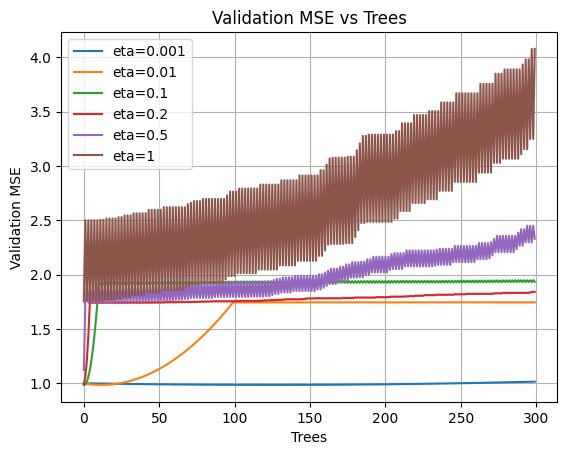

eta=0.001 | best_iter=126 | test_MSE=0.9723
eta=0.01 | best_iter=12 | test_MSE=0.9729
eta=0.1 | best_iter=1 | test_MSE=0.9753
eta=0.2 | best_iter=1 | test_MSE=0.9711
eta=0.5 | best_iter=1 | test_MSE=1.0777
eta=1 | best_iter=1 | test_MSE=1.6554


In [5]:
import numpy as np
import matplotlib.pyplot as plt


data = np.load("mnist.npz")

X_train, y_train = data["x_train"], data["y_train"]
X_test, y_test = data["x_test"], data["y_test"]


X_train = X_train.reshape(60000, -1) / 255.0
X_test = X_test.reshape(10000, -1) / 255.0


mask_train = (y_train == 4) | (y_train == 9)
mask_test = (y_test == 4) | (y_test == 9)

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Convert labels
y_train = np.where(y_train == 4, -1, 1)
y_test = np.where(y_test == 4, -1, 1)

# Split validation (1000 each)
idx_neg = np.where(y_train == -1)[0]
idx_pos = np.where(y_train == 1)[0]

np.random.shuffle(idx_neg)
np.random.shuffle(idx_pos)

val_idx = np.concatenate((idx_neg[:1000], idx_pos[:1000]))
train_idx = np.concatenate((idx_neg[1000:], idx_pos[1000:]))

X_val = X_train[val_idx]
y_val = y_train[val_idx]

X_train = X_train[train_idx]
y_train = y_train[train_idx]


mean = np.mean(X_train, axis=0)
X_centered = X_train - mean

cov = np.cov(X_centered, rowvar=False)
eig_vals, eig_vecs = np.linalg.eigh(cov)

idx = np.argsort(eig_vals)[::-1]
W = eig_vecs[:, idx[:5]]

X_train = (X_train - mean) @ W
X_val = (X_val - mean) @ W
X_test = (X_test - mean) @ W


def find_best_stump(X, y):
    n_samples, n_features = X.shape

    best_feature = -1
    best_threshold = 0
    best_polarity = 1
    min_error = float('inf')

    for j in range(n_features):
        X_j = X[:, j]

        sorted_vals = np.sort(X_j)

        midpoints = (sorted_vals[:-1] + sorted_vals[1:]) / 2

        if len(midpoints) > 1000:
            idx = np.random.choice(len(midpoints), 1000, replace=False)
            thresholds = midpoints[idx]
        else:
            thresholds = midpoints

        for t in thresholds:
            for polarity in [1, -1]:

                preds = np.ones(n_samples)

                if polarity == 1:
                    preds[X_j < t] = -1
                else:
                    preds[X_j < t] = 1

                error = np.sum(preds != y)

                if error < min_error:
                    min_error = error
                    best_feature = j
                    best_threshold = t
                    best_polarity = polarity

    return best_feature, best_threshold, best_polarity


def stump_predict(X, feature, threshold, polarity):
    preds = np.ones(len(X))
    if polarity == 1:
        preds[X[:, feature] < threshold] = -1
    else:
        preds[X[:, feature] < threshold] = 1
    return preds


etas = [0.001, 0.01, 0.1, 0.2, 0.5, 1]
T = 300

results = {}

for eta in etas:

    F_train = np.zeros(len(X_train))
    F_val = np.zeros(len(X_val))

    stumps = []
    val_mse_list = []

    for t in range(T):

        # gradients (absolute loss)
        gradients = np.sign(y_train - F_train)

        # train stump
        f, th, pol = find_best_stump(X_train, gradients)

        stumps.append((f, th, pol))

        # update train
        preds_train = stump_predict(X_train, f, th, pol)
        F_train += eta * preds_train

        # update validation
        preds_val = stump_predict(X_val, f, th, pol)
        F_val += eta * preds_val

        # compute MSE
        mse = np.mean((y_val - F_val) ** 2)
        val_mse_list.append(mse)

    results[eta] = {
        "mse": val_mse_list,
        "stumps": stumps
    }


for eta in etas:
    plt.plot(results[eta]["mse"], label=f"eta={eta}")

plt.xlabel("Trees")
plt.ylabel("Validation MSE")
plt.title("Validation MSE vs Trees")
plt.legend()
plt.grid()
plt.show()

for eta in etas:

    mse_list = results[eta]["mse"]
    stumps = results[eta]["stumps"]

    best_iter = np.argmin(mse_list) + 1

    F_test = np.zeros(len(X_test))

    for t in range(best_iter):
        f, th, pol = stumps[t]
        preds = stump_predict(X_test, f, th, pol)
        F_test += eta * preds

    test_mse = np.mean((y_test - F_test) ** 2)

    print(f"eta={eta} | best_iter={best_iter} | test_MSE={test_mse:.4f}")

Converged at epoch 2


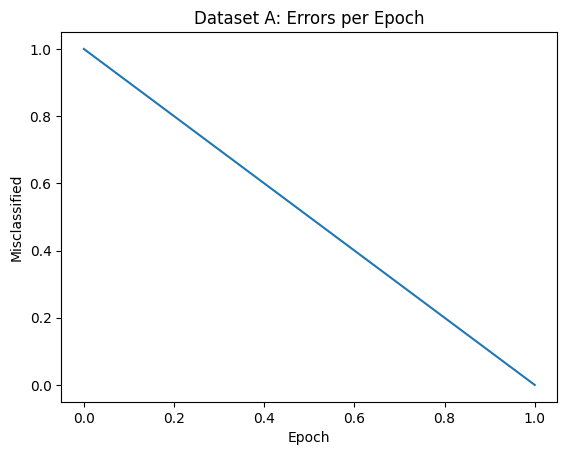

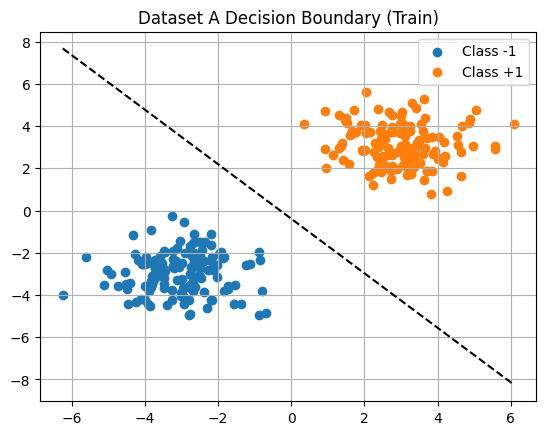

Dataset A Test Accuracy: 1.0


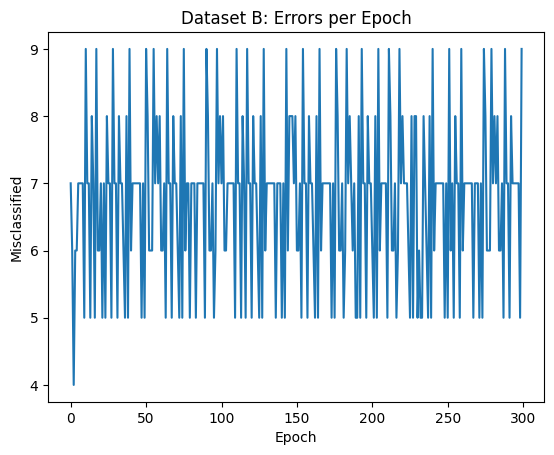

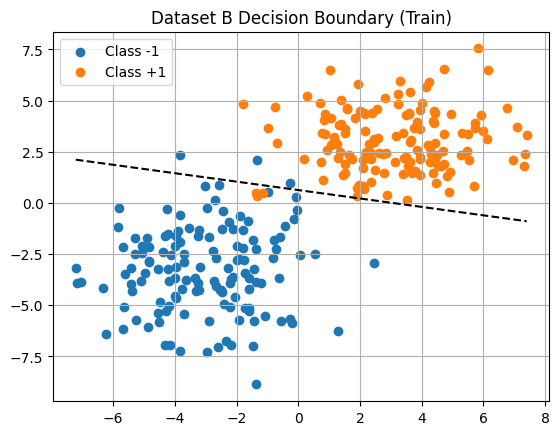

Dataset B Test Accuracy: 0.9666666666666667


In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def generate_data(cov_scale=1):

    mean_neg = [-3, -3]
    mean_pos = [3, 3]

    cov = cov_scale * np.eye(2)

    X_neg = np.random.multivariate_normal(mean_neg, cov, 200)
    X_pos = np.random.multivariate_normal(mean_pos, cov, 200)

    X = np.vstack((X_neg, X_pos))
    y = np.hstack((-1*np.ones(200), np.ones(200)))

    return X, y


def split_data(X, y):
    idx = np.arange(len(X))
    np.random.shuffle(idx)

    split = int(0.7 * len(X))

    train_idx = idx[:split]
    test_idx = idx[split:]

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


def perceptron_train(X, y, eta=0.01, max_epochs=300):

    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0

    errors_per_epoch = []

    for epoch in range(max_epochs):

        errors = 0

        for i in range(n_samples):

            if y[i] * (np.dot(w, X[i]) + b) <= 0:
                w = w + eta * y[i] * X[i]
                b = b + eta * y[i]
                errors += 1

        errors_per_epoch.append(errors)

        # Early stopping
        if errors == 0:
            print(f"Converged at epoch {epoch+1}")
            break

    return w, b, errors_per_epoch


def predict(X, w, b):
    return np.sign(X @ w + b)


def plot_boundary(X, y, w, b, title):

    plt.figure()

    # scatter
    plt.scatter(X[y==-1][:,0], X[y==-1][:,1], label="Class -1")
    plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class +1")

    # decision boundary
    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    y_vals = -(w[0]*x_vals + b) / w[1]

    plt.plot(x_vals, y_vals, 'k--')

    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()



X_A, y_A = generate_data(cov_scale=1)
X_train_A, y_train_A, X_test_A, y_test_A = split_data(X_A, y_A)

w_A, b_A, errors_A = perceptron_train(X_train_A, y_train_A)

# Plot errors
plt.plot(errors_A)
plt.title("Dataset A: Errors per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified")
plt.show()

# Plot boundary
plot_boundary(X_train_A, y_train_A, w_A, b_A, "Dataset A Decision Boundary (Train)")

# Test accuracy
preds_A = predict(X_test_A, w_A, b_A)
acc_A = np.mean(preds_A == y_test_A)
print("Dataset A Test Accuracy:", acc_A)


# ----------------------------
# RUN FOR DATASET B
# ----------------------------
X_B, y_B = generate_data(cov_scale=3)
X_train_B, y_train_B, X_test_B, y_test_B = split_data(X_B, y_B)

w_B, b_B, errors_B = perceptron_train(X_train_B, y_train_B)

# Plot errors
plt.plot(errors_B)
plt.title("Dataset B: Errors per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified")
plt.show()

# Plot boundary
plot_boundary(X_train_B, y_train_B, w_B, b_B, "Dataset B Decision Boundary (Train)")

# Test accuracy
preds_B = predict(X_test_B, w_B, b_B)
acc_B = np.mean(preds_B == y_test_B)
print("Dataset B Test Accuracy:", acc_B)
